# DDPG로 Pendulum-v1 풀기

## 실습 목표
논문 *Continuous control with deep reinforcement learning* (Lillicrap et al., 2015) 의 DDPG 알고리즘을 직접 구현하고,  
Pendulum-v1 환경에서 진자를 위로 세우는 문제를 학습시킨다.

---

## Pendulum-v1 이란?

- **문제**: 아래로 늘어진 진자를 위로 세워서 유지하는 것
- **상태(State)**: 진자의 각도(cos, sin), 각속도 → 총 3개의 숫자
- **행동(Action)**: 진자에 가하는 토크 → **-2.0 ~ +2.0 사이의 연속값** ← DDPG가 필요한 이유!
- **보상(Reward)**: 진자가 똑바로 서 있을수록 보상이 높다

DQN으로는 '토크 = 1.37' 같은 연속값을 출력할 수 없다.  
DDPG는 Actor 네트워크가 연속값을 직접 출력하기 때문에 이 문제를 풀 수 있다.

---

## 📋 논문 → 코드 대응표

| 논문 개념 | 코드에서 구현되는 곳 |
|----------|--------------------|
| Actor Network | `Actor` 클래스 |
| Critic Network | `Critic` 클래스 |
| Replay Buffer | `ReplayBuffer` 클래스 |
| Target Network | `actor_target`, `critic_target` |
| Soft Update (τ) | `soft_update()` 함수 |
| Exploration Noise | `OUNoise` 클래스 |
| Bellman Equation | `train()` 함수 내 `target_q` 계산 |


## Step 1. 환경 설치

코랩은 기본적으로 GPU 환경이 없어도 이 실습은 돌아간다.  
gymnasium은 OpenAI Gym의 최신 버전이다.

In [1]:
!pip install gymnasium[classic-control] -q

## Step 2. 라이브러리 불러오기

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

# 재현성을 위한 시드 고정
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

사용 디바이스: cuda


## Step 3. Actor 네트워크

### 📌 논문에서 뭐라고 했나?
> *"The actor specifies the current policy by deterministically mapping states to a specific action."*  
> (Actor는 상태를 행동으로 결정론적으로 매핑하는 정책을 정의한다)

### 🗣️ 쉽게 말하면
Actor는 **"지금 상황을 보고 어떤 행동을 할지 결정하는 뇌"** 다.  
입력: 진자의 현재 상태 (각도, 각속도)  
출력: 토크 값 하나 (-2.0 ~ +2.0)

마지막에 `tanh`를 쓰는 이유: tanh는 출력을 -1 ~ +1 사이로 만들어준다.  
여기에 `max_action`(=2.0)을 곱하면 -2.0 ~ +2.0 범위가 된다.

In [3]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super(Actor, self).__init__()
        self.max_action = max_action

        # 논문: 400, 300 유닛의 은닉층 사용
        self.net = nn.Sequential(
            nn.Linear(state_dim, 400),   # 입력층 → 은닉층1
            nn.ReLU(),
            nn.Linear(400, 300),          # 은닉층1 → 은닉층2
            nn.ReLU(),
            nn.Linear(300, action_dim),   # 은닉층2 → 출력층
            nn.Tanh()                     # 출력을 -1 ~ +1 로 압축
        )

    def forward(self, state):
        # max_action 곱해서 실제 행동 범위로 변환
        return self.max_action * self.net(state)

## Step 4. Critic 네트워크

### 📌 논문에서 뭐라고 했나?
> *"The critic estimates the value function Q(s, a), which represents the expected cumulative reward."*  
> (Critic은 Q함수를 추정하며, Q함수는 기대 누적 보상을 나타낸다)

### 🗣️ 쉽게 말하면
Critic은 **"Actor가 내린 행동이 얼마나 좋은 선택이었는지 점수를 매기는 뇌"** 다.  
입력: 상태 + 행동 (둘 다 받는다!)  
출력: Q값 (숫자 하나, 높을수록 좋은 행동)

상태와 행동을 두 번째 레이어에서 합치는 이유:  
논문에서 "action을 두 번째 hidden layer에서 입력으로 넣는다"고 명시했기 때문이다.

In [4]:
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()

        # 상태만 먼저 처리하는 레이어
        self.layer1 = nn.Linear(state_dim, 400)

        # 두 번째 레이어에서 행동을 합친다 (논문 구조 그대로)
        self.layer2 = nn.Linear(400 + action_dim, 300)
        self.layer3 = nn.Linear(300, 1)   # Q값 하나 출력

    def forward(self, state, action):
        x = torch.relu(self.layer1(state))          # 상태 처리
        x = torch.cat([x, action], dim=1)           # 행동과 합치기
        x = torch.relu(self.layer2(x))              # 합쳐서 처리
        return self.layer3(x)                        # Q값 반환

## Step 5. Replay Buffer

### 📌 논문에서 뭐라고 했나?
> *"We used a replay buffer to address the problem of correlated data.  
> Transitions were sampled from the environment and stored in a buffer."*  
> (상관된 데이터 문제를 해결하기 위해 Replay Buffer를 사용했다)

### 🗣️ 쉽게 말하면
AI가 경험한 것들을 **일기장에 기록**해두는 것이다.  
일기장에서 **무작위로 꺼내서** 학습하면, 연속된 경험의 패턴에 과적합되는 걸 막을 수 있다.  

예를 들어 AI가 방금 "왼쪽으로 쏠렸다 → 오른쪽 토크 → 보상 +1" 을 10번 연속으로 경험했다고 하자.  
이걸 순서대로 학습하면 "항상 오른쪽만 밀면 된다"고 잘못 배울 수 있다.  
랜덤하게 섞어서 학습하면 이 문제가 해결된다.

In [5]:
class ReplayBuffer:
    def __init__(self, max_size=100000):
        # deque: 꽉 차면 오래된 것부터 자동으로 삭제된다
        self.buffer = deque(maxlen=max_size)

    def push(self, state, action, reward, next_state, done):
        # 경험 하나를 저장 (상태, 행동, 보상, 다음상태, 종료여부)
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        # 무작위로 batch_size 개만큼 꺼내기
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)

        return (
            torch.FloatTensor(np.array(state)).to(device),
            torch.FloatTensor(np.array(action)).to(device),
            torch.FloatTensor(np.array(reward)).unsqueeze(1).to(device),
            torch.FloatTensor(np.array(next_state)).to(device),
            torch.FloatTensor(np.array(done)).unsqueeze(1).to(device)
        )

    def __len__(self):
        return len(self.buffer)

## Step 6. Exploration Noise (OU Noise)

### 📌 논문에서 뭐라고 했나?
> *"We constructed an exploration policy by adding noise sampled from an Ornstein-Uhlenbeck process."*  
> (OU 프로세스에서 샘플링한 노이즈를 더해서 탐험 정책을 구성했다)

### 🗣️ 쉽게 말하면
AI가 처음부터 최적 행동만 고집하면 **다양한 상황을 경험하지 못한다.**  
그래서 의도적으로 행동에 **랜덤 노이즈**를 추가해서 탐험하게 만든다.

OU Noise는 일반 랜덤 노이즈와 달리 **이전 노이즈 값 근처에서 부드럽게 움직인다.**  
물리적 시스템(로봇, 진자)에서 갑작스러운 행동 변화를 방지하는 데 적합하다.

In [6]:
class OUNoise:
    def __init__(self, action_dim, mu=0.0, theta=0.15, sigma=0.2):
        self.mu = mu          # 평균값 (0으로 수렴)
        self.theta = theta    # 평균으로 돌아오는 속도
        self.sigma = sigma    # 노이즈 크기
        self.state = np.ones(action_dim) * self.mu

    def reset(self):
        self.state = np.ones_like(self.state) * self.mu

    def sample(self):
        # OU 프로세스: 이전 값에서 조금씩 변화
        dx = self.theta * (self.mu - self.state) + self.sigma * np.random.randn(len(self.state))
        self.state += dx
        return self.state

## Step 7. DDPG 에이전트 (핵심!)

### 📌 논문에서 뭐라고 했나?
> *"We maintained a parameterized actor and critic, along with target networks for both.  
> The target networks are updated using soft updates: θ' ← τθ + (1-τ)θ'"*  
> (Actor/Critic 각각 타깃 네트워크를 유지하며, Soft Update로 천천히 업데이트한다)

### 🗣️ 쉽게 말하면
총 4개의 네트워크가 사용된다.

| 네트워크 | 역할 |
|---------|------|
| Actor | 실제로 행동 결정 |
| Actor Target | 학습 목표 계산용 (느리게 업데이트) |
| Critic | 실제로 Q값 계산 |
| Critic Target | 학습 목표 계산용 (느리게 업데이트) |

Target 네트워크가 필요한 이유:  
학습 목표(y)가 계속 바뀌면 학습이 불안정해진다.  
Target 네트워크는 τ=0.005 비율로 **아주 천천히** 업데이트해서 목표가 급변하는 걸 막는다.

Soft Update 수식:  
`타깃 가중치 = τ × 현재 가중치 + (1-τ) × 타깃 가중치`  
τ가 0.005면 타깃은 매 스텝 0.5%씩만 바뀐다.

In [7]:
class DDPGAgent:
    def __init__(self, state_dim, action_dim, max_action):

        # ── Actor / Actor Target ──
        self.actor = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target.load_state_dict(self.actor.state_dict())  # 처음엔 동일하게 시작
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=1e-4)

        # ── Critic / Critic Target ──
        self.critic = Critic(state_dim, action_dim).to(device)
        self.critic_target = Critic(state_dim, action_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=1e-3)

        self.replay_buffer = ReplayBuffer()
        self.noise = OUNoise(action_dim)
        self.max_action = max_action

        # 하이퍼파라미터
        self.gamma = 0.99    # 할인율: 미래 보상을 얼마나 중시할지
        self.tau = 0.005     # Soft Update 비율
        self.batch_size = 64

    def select_action(self, state, add_noise=True):
        """행동 선택: Actor가 출력한 행동 + 탐험 노이즈"""
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        self.actor.eval()
        with torch.no_grad():
            action = self.actor(state).cpu().numpy()[0]
        self.actor.train()

        if add_noise:
            action += self.noise.sample()  # 탐험을 위한 노이즈 추가

        return np.clip(action, -self.max_action, self.max_action)

    def soft_update(self, net, target_net):
        """타깃 네트워크를 천천히 업데이트 (논문의 핵심 안정화 장치)"""
        for param, target_param in zip(net.parameters(), target_net.parameters()):
            target_param.data.copy_(
                self.tau * param.data + (1 - self.tau) * target_param.data
            )

    def train(self):
        """Replay Buffer에서 샘플링해서 Actor/Critic 업데이트"""
        if len(self.replay_buffer) < self.batch_size:
            return  # 버퍼가 충분히 차기 전까지는 학습 안 함

        state, action, reward, next_state, done = self.replay_buffer.sample(self.batch_size)

        # ── Critic 업데이트 ──
        # 논문의 Bellman Equation:
        # y = r + γ * Q'(s', μ'(s'))  (타깃 네트워크로 계산)
        with torch.no_grad():
            next_action = self.actor_target(next_state)           # 다음 행동 (타깃 Actor)
            target_q = reward + self.gamma * (1 - done) * self.critic_target(next_state, next_action)  # 목표 Q값

        current_q = self.critic(state, action)                    # 현재 Q값
        critic_loss = nn.MSELoss()(current_q, target_q)          # 목표와 현재의 차이

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # ── Actor 업데이트 ──
        # 논문: Actor는 Critic의 Q값을 최대화하는 방향으로 업데이트
        actor_loss = -self.critic(state, self.actor(state)).mean()  # Q값의 음수 = 손실

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # ── Soft Update ──
        self.soft_update(self.critic, self.critic_target)
        self.soft_update(self.actor, self.actor_target)

## Step 8. 학습 실행

### 🗣️ 전체 흐름 설명

```
에피소드 시작
    ↓
Actor가 현재 상태 보고 행동 결정
    ↓
환경에서 행동 실행 → 보상 받기
    ↓
경험을 Replay Buffer에 저장
    ↓
Buffer에서 랜덤 샘플링 → Critic 업데이트 → Actor 업데이트
    ↓
Target Network Soft Update
    ↓
에피소드 종료까지 반복
```

**예상 소요 시간**: 코랩 CPU 기준 약 10~20분 (200 에피소드 기준)

In [8]:
# 환경 생성
env = gym.make('Pendulum-v1')

state_dim = env.observation_space.shape[0]    # 3 (cos, sin, 각속도)
action_dim = env.action_space.shape[0]         # 1 (토크)
max_action = float(env.action_space.high[0])   # 2.0

print(f'상태 차원: {state_dim}')
print(f'행동 차원: {action_dim}')
print(f'최대 행동값: {max_action}')

agent = DDPGAgent(state_dim, action_dim, max_action)

# 학습 설정
max_episodes = 200
max_steps = 200
reward_history = []

for episode in range(max_episodes):
    state, _ = env.reset()
    agent.noise.reset()     # 에피소드 시작마다 노이즈 초기화
    episode_reward = 0

    for step in range(max_steps):
        # 1. 행동 선택
        action = agent.select_action(state, add_noise=True)

        # 2. 환경에서 행동 실행
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # 3. Replay Buffer에 경험 저장
        agent.replay_buffer.push(state, action, reward, next_state, float(done))

        # 4. 학습
        agent.train()

        state = next_state
        episode_reward += reward

        if done:
            break

    reward_history.append(episode_reward)

    # 10 에피소드마다 진행상황 출력
    if (episode + 1) % 10 == 0:
        avg_reward = np.mean(reward_history[-10:])
        print(f'에피소드 {episode+1:3d} | 평균 보상: {avg_reward:.1f}')

env.close()
print('\n학습 완료!')

상태 차원: 3
행동 차원: 1
최대 행동값: 2.0
에피소드  10 | 평균 보상: -1393.4
에피소드  20 | 평균 보상: -1084.2
에피소드  30 | 평균 보상: -250.8
에피소드  40 | 평균 보상: -189.0
에피소드  50 | 평균 보상: -327.1
에피소드  60 | 평균 보상: -317.4
에피소드  70 | 평균 보상: -170.3
에피소드  80 | 평균 보상: -201.1
에피소드  90 | 평균 보상: -192.2
에피소드 100 | 평균 보상: -197.7
에피소드 110 | 평균 보상: -188.9
에피소드 120 | 평균 보상: -136.0
에피소드 130 | 평균 보상: -169.0
에피소드 140 | 평균 보상: -238.5
에피소드 150 | 평균 보상: -124.3
에피소드 160 | 평균 보상: -193.2
에피소드 170 | 평균 보상: -199.7
에피소드 180 | 평균 보상: -179.8
에피소드 190 | 평균 보상: -214.8
에피소드 200 | 평균 보상: -199.8

학습 완료!


## Step 9. 학습 결과 시각화

### 🗣️ 그래프 보는 법
- Pendulum-v1의 최대 보상은 에피소드당 약 **-200 이상**이면 잘 학습된 것이다
- 처음에는 -1500 ~ -1000 수준으로 시작해서 점점 올라가는 게 정상이다
- 학습이 잘 됐다면 후반부에 **-200 ~ -100 근처**로 수렴한다

/tmp/ipykernel_1169/4069171300.py:21: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1169/4069171300.py:21: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1169/4069171300.py:21: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1169/4069171300.py:21: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1169/4069171300.py:21: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1169/4069171300.py:21: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1169/4069171300.py:21: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layo

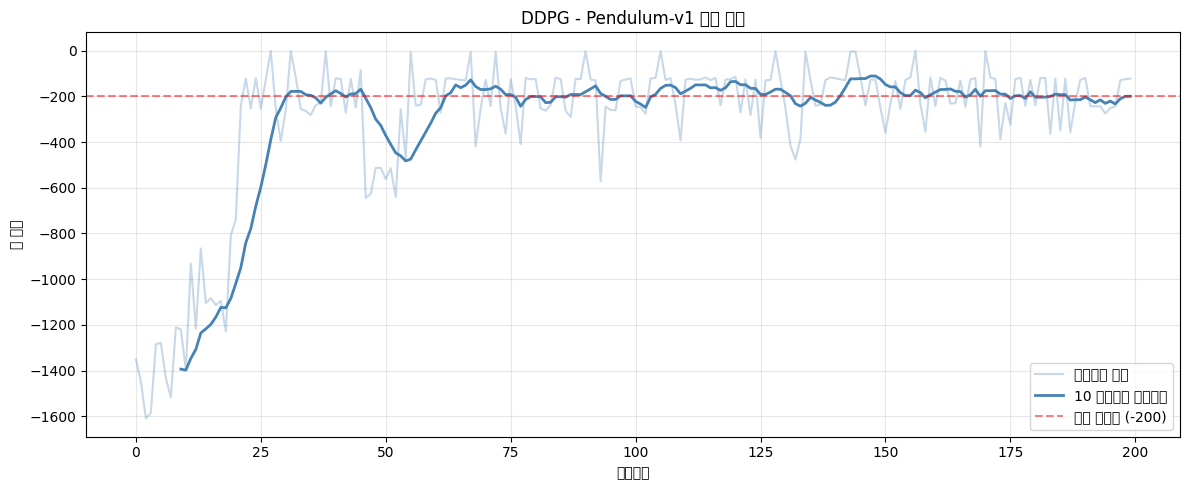


최종 10 에피소드 평균 보상: -199.8
전체 최고 보상: -0.4


In [9]:
# 이동 평균 계산
def moving_average(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 5))

# 원본 보상
plt.plot(reward_history, alpha=0.3, color='steelblue', label='에피소드 보상')

# 이동 평균
if len(reward_history) >= 10:
    ma = moving_average(reward_history, window=10)
    plt.plot(range(9, len(reward_history)), ma, color='steelblue', linewidth=2, label='10 에피소드 이동평균')

plt.axhline(y=-200, color='red', linestyle='--', alpha=0.5, label='목표 기준선 (-200)')
plt.xlabel('에피소드')
plt.ylabel('총 보상')
plt.title('DDPG - Pendulum-v1 학습 곡선')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n최종 10 에피소드 평균 보상: {np.mean(reward_history[-10:]):.1f}')
print(f'전체 최고 보상: {max(reward_history):.1f}')

## Step 10. 학습된 에이전트 테스트

### 🗣️ 설명
학습 때는 노이즈를 추가해서 탐험했다면,  
테스트 때는 `add_noise=False` 로 설정해서 **순수하게 학습된 정책만** 사용한다.

In [10]:
env_test = gym.make('Pendulum-v1')
test_rewards = []

for test_ep in range(5):
    state, _ = env_test.reset()
    ep_reward = 0

    for _ in range(200):
        action = agent.select_action(state, add_noise=False)  # 노이즈 없이 테스트
        next_state, reward, terminated, truncated, _ = env_test.step(action)
        done = terminated or truncated
        state = next_state
        ep_reward += reward
        if done:
            break

    test_rewards.append(ep_reward)
    print(f'테스트 에피소드 {test_ep+1}: 보상 = {ep_reward:.1f}')

env_test.close()
print(f'\n테스트 평균 보상: {np.mean(test_rewards):.1f}')

테스트 에피소드 1: 보상 = -243.5
테스트 에피소드 2: 보상 = -124.5
테스트 에피소드 3: 보상 = -253.7
테스트 에피소드 4: 보상 = -121.0
테스트 에피소드 5: 보상 = -241.7

테스트 평균 보상: -196.9


---

## 📝 전체 요약

| 코드 구성 요소 | 논문 개념 | 역할 |
|--------------|----------|------|
| `Actor` 클래스 | Deterministic Policy | 상태 → 연속 행동 출력 |
| `Critic` 클래스 | Q-value Function | (상태, 행동) → 점수 |
| `ReplayBuffer` | Experience Replay | 경험 저장 후 랜덤 샘플링 |
| `actor_target`, `critic_target` | Target Network | 학습 안정화용 느린 네트워크 |
| `soft_update()` | Soft Update (τ=0.005) | 타깃 네트워크 천천히 갱신 |
| `OUNoise` | Exploration Noise | 탐험을 위한 노이즈 추가 |
| `target_q` 계산 | Bellman Equation | 미래 보상 포함한 학습 목표 |

---

## 💡 더 해볼 것

1. `max_episodes`를 500으로 늘려서 더 오래 학습시켜보기
2. `gamma` 값을 0.9로 낮추면 어떻게 달라지는지 비교하기
3. `tau` 값을 0.01로 키우면 학습이 불안정해지는지 확인하기
4. `MountainCarContinuous-v0` 환경으로 바꿔서 돌려보기